# 6. Saturated stars

### Setup notebook

In [2]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

### Imports

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PlatoSim
import platosim.plot            as pt
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [4]:
# Output everything in the current working directory
outputDir = os.getcwd()

---
## 6.1 - Saturation and blooming
---

We here have a look at the bright limit of PLATO, namely saturated stars.

In [6]:
# Set up a Simulation object
sim = Simulation("output_example1", outputDir=outputDir)

# Obs
sim["ObservingParameters/NumExposures"] = 1

# Select subfield size and location
sim["SubField/NumColumns"]      = 60
sim["SubField/NumRows"]         = 100
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
mag = np.array([9.0, 8.5, 8.0, 7.5, 7.0, 6.5, 6.0, 5.5, 5.0, 4.5])
row = np.ones(len(mag)) * 50 + sim["SubField/ZeroPointRow"]
col = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50]) + sim["SubField/ZeroPointColumn"]
starID = np.arange(len(mag))

# Create and set stellar catalogue file
starcatFile = outputDir + "/starcat_example1.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

# Save only the eneded output
sim.turnOffAllOutput()
sim["ControlHDF5Content/GroupByExposure"]    = True
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteSmearingMaps"]  = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

# Save the PSF
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Run simulation for 1 day
simfile = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:00:00.463138 [hh:mm:ss]


Below we show the increasing effect of blooming with decreasing magnitude of each star going from left to right:

In [7]:
f = SimFile("output_example1.hdf5")

<IPython.core.display.Javascript object>


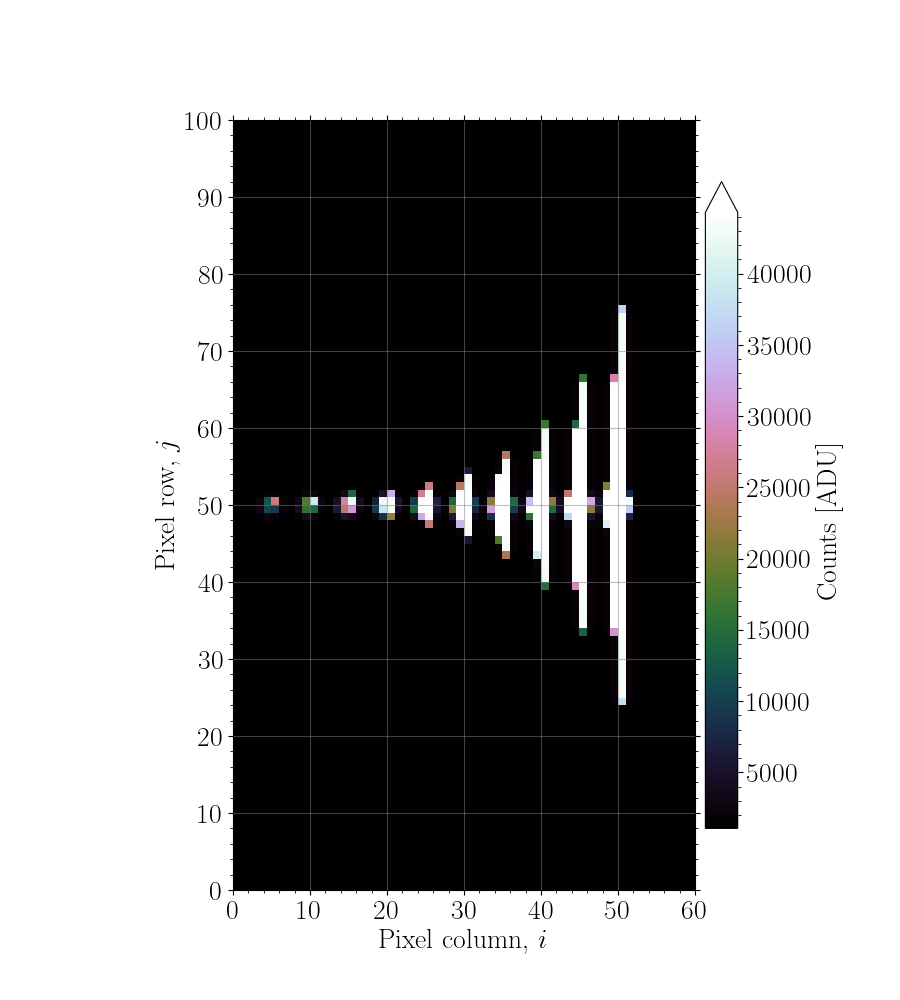

In [8]:
fig, ax = f.showImage(0, clipPercentile=1, imgScale="clip", 
                      fontSize=20, figsize=(9,10), 
                      showStarPositions=False, 
                      colorBar=True, showGrid=True);

Saturation/blooming cause a so-called readout smearing effect, since photons from bright stars are still received by the detector as the exposure during readout. The reason hereto is because the PLATO CCD's do not have a physical shutter. Below we simply change the image scale to visualise how this effect evolves with stellar brightness: 

<IPython.core.display.Javascript object>


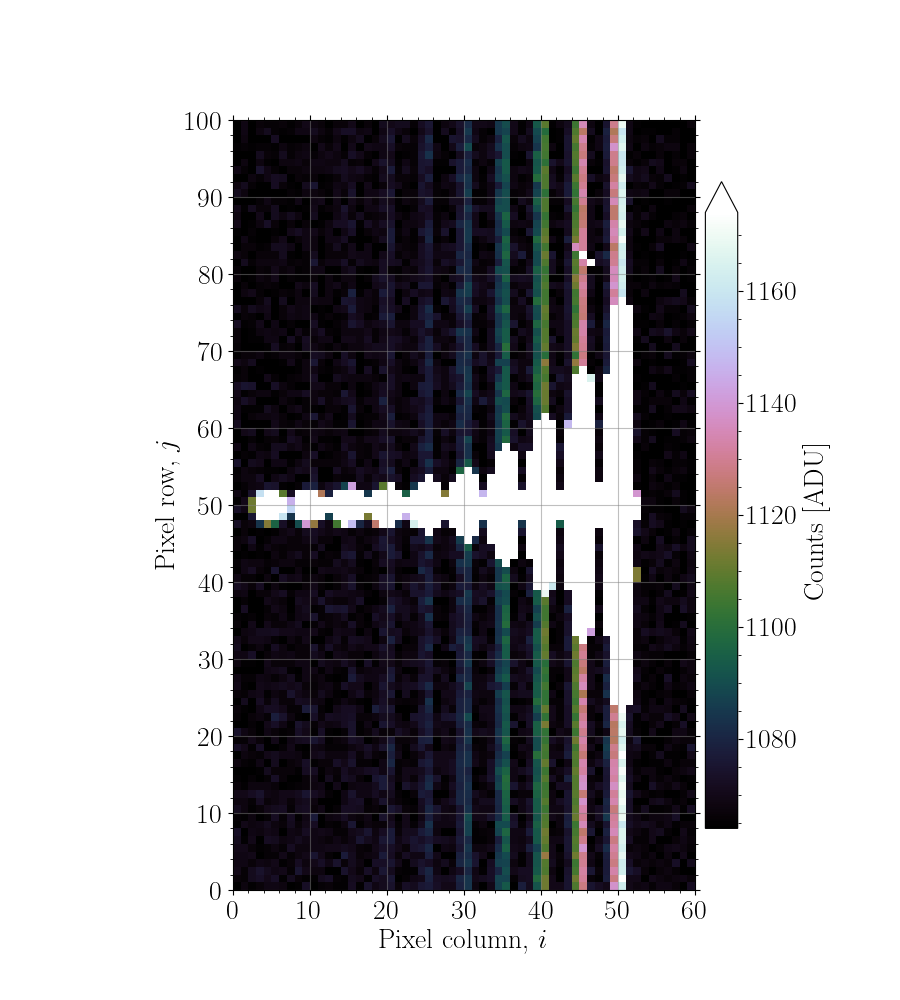

In [9]:
fig, ax = simfile.showImage(0, clipPercentile=10, imgScale="clip", 
                      fontSize=20, figsize=(9,10), 
                      showStarPositions=False, 
                      colorBar=True, showGrid=True);

It is clear that extracting photometry of saturated stars are a complicated task, since the exact blooming trails depends highly on the intra-pixel position of each source PSF and additionally on what happens when introducing systematic effects that displace the PSF over time. Depending on the level of saturation several methods exist to extract the photometry in the bright limit. These can generally be seperated into two groups: those that conserve the stellar flux and those that don't.

---
## 6.2 - Saturation and ghost images
---

Like all instruments PLATO has two dominating ghost images, which originating from scattered light from one or more surfaces back to the CCD detector. These are one *extended* and one *point-like* ghost image. The extended is in most cases ontop of the source PSF (while is slowly moved further away with increasing distance to the optical axis) and can aprroximately be described by a uniform disk of incident light. The point-like ghost exist in principle only for a source image within 8 degrees from the optical axis and has a image PSF very similar to the source PSF (hence PlatoSim assumes they are identical). Below we show how the poin-like ghost image are actually displaced to another CCD opposite of the optical axis:

<IPython.core.display.Javascript object>


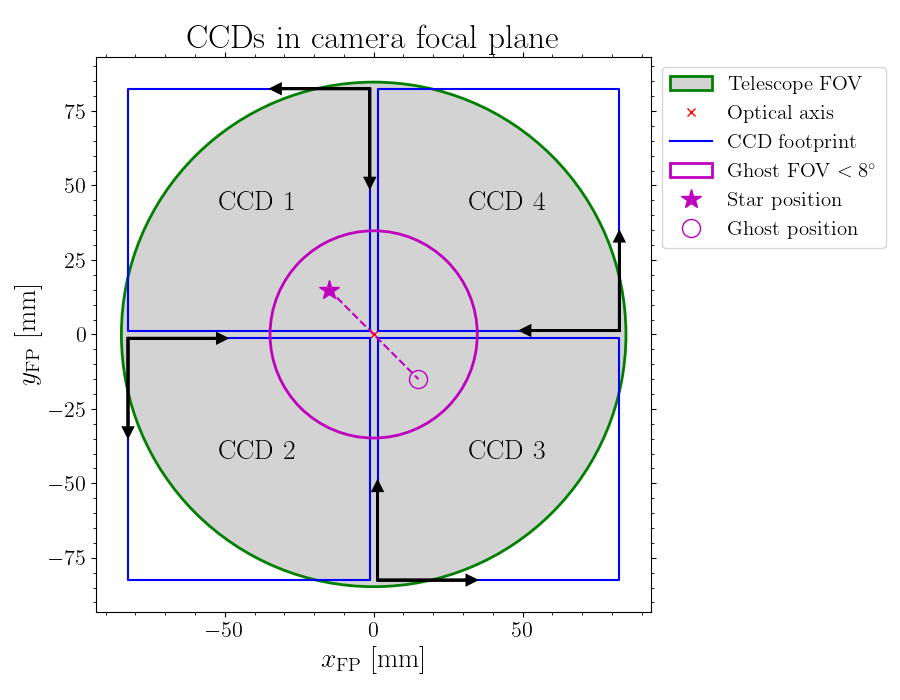

In [66]:
# Parameters for PLATO
pixelSize   = 18        # [µm]
plateScale  = 15        # [arcsec]
fovGhost    = 8.0       # [deg]
focalLength = 247.52    # [mm]

# Calculate the maximum FOV for a point-like ghost creation [mm]
fovGhost = focalLength * np.tan(np.radians(fovGhost))

fig = plt.figure(figsize=(9,7))

# Plotting
ax = pt.drawCCDsInCameraFocalPlane(fig)
c = plt.Circle((0, 0), radius=fovGhost, color="none", linewidth=2, label=r"Ghost FOV $<8^{\circ}$", zorder=4)
c.set_edgecolor("m")
ax.add_patch(c)
ax.plot(-15, 15, '*', c='m', ms=15, label='Star position', zorder=5)
ax.plot(15, -15, 'o', c='m', ms=13, fillstyle="none", label='Ghost position', zorder=6)
ax.plot([-15, 15], [15, -15], '--', c='m', zorder=7)

# Settings
plt.legend(bbox_to_anchor=(1.0,1.0))
ax.set_aspect('equal', 'box')
plt.tight_layout();

---
## 6.3 - Photometry of saturated stars
---

### Smear photometry

For brightest stars (i.e. $V<2$) so-called smear-photometry, which uses the parallel overscan rows to determine the smearing maps, may be a potential way to extract the photometric flux of the stars for PLATO. The importance of correction for smearing is also quite evident from the simulated smearing maps shown below:

<IPython.core.display.Javascript object>


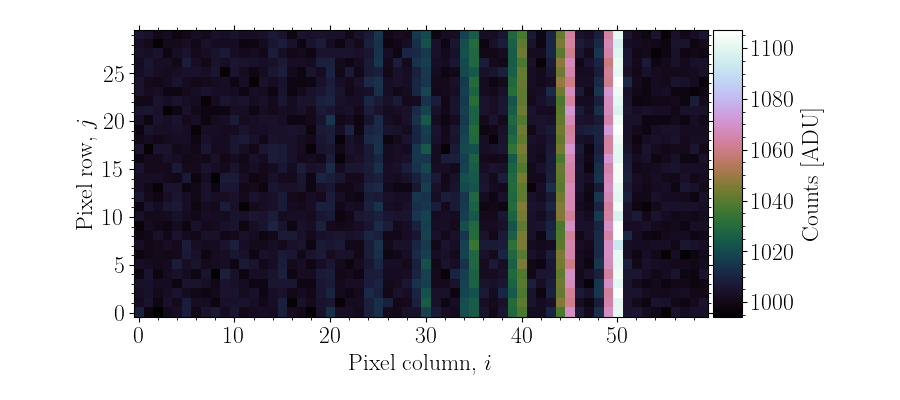

In [57]:
sm = f.getSmearingMap(0)
f.showMap(sm, figsize=(9,4));

### Ghost photometry

<IPython.core.display.Javascript object>


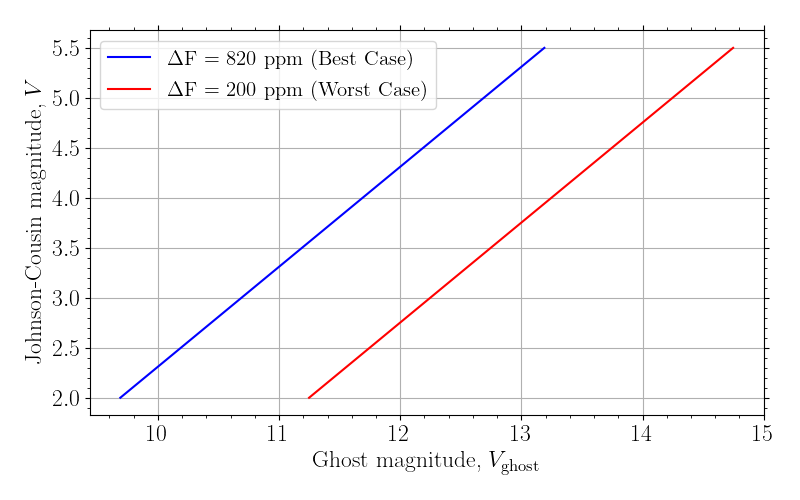

In [16]:
# User defined params:
Teff = 6000
V = np.arange(2.0, 6.0, 0.5)

# Find ghost magnitude
Vghost_BC = V + 2.5*np.log10(1/0.00084)
Vghost_WC = V + 2.5*np.log10(1/0.00020)

# Start plot
fig = plt.figure(figsize=(8,5))
plt.plot(Vghost_BC, P, 'b-', label=r'$\Delta$F = 820 ppm (Best  Case)')
plt.plot(Vghost_WC, P, 'r-', label=r'$\Delta$F = 200 ppm (Worst Case)')
plt.xlabel(r'Ghost magnitude, $V_{\rm ghost}$')
plt.ylabel(r'Johnson-Cousin magnitude, $V$')
plt.grid()
plt.legend()
plt.tight_layout()

---
## 6.1 -  
---

Hej

Let's run and visualise the simulation for the first exposure:

<IPython.core.display.Javascript object>


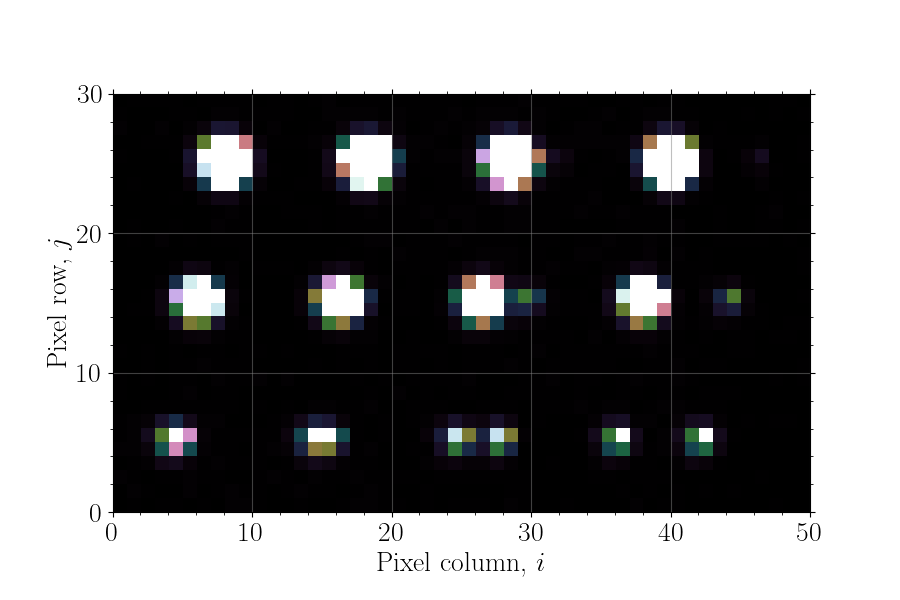

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [73]:
fig, ax = simfile.showImage(clipPercentile=5, imgScale="clip", fontSize=20, figsize=(9,6),
                            colorMap="cubehelix", colorBar=False, showGrid=True);

---
## Create a GIF of your simulation
---

In [1]:
from platosim.plot import plotSubfieldAnimation

In [ ]:
idir = "/lhome/nicholas/software/workdir/test/output"
filename = idir + "/000000000_Ncam1.1_Q1.hdf5"
plotSubfieldAnimation(filename, outputFileName=idir+"/animation", showStarPositions="PIC", 
                      skipNimages=1000, showMaskOfStarID=1)